In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys


sys.path.append(os.path.abspath('..'))

from src.models.lee_carter import fit_lee_carter, reconstruct_mx, forecast_kt
from src.models.life_expectancy import compute_life_expectancy, compute_life_table

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [ ]:
df_deaths = pd.read_csv("../data/france_deaths_clean.csv")
df_pop = pd.read_csv("../data/france_population_clean.csv")

df_deaths_long = df_deaths.melt(
    id_vars=['Year', 'Age'], 
    value_vars=['Male', 'Female'], 
    var_name='Sex', 
    value_name='Deaths'
)

df_pop_long = df_pop.melt(
    id_vars=['Year', 'Age'], 
    value_vars=['Male', 'Female'], 
    var_name='Sex', 
    value_name='Population'
)

df_full = pd.merge(df_deaths_long, df_pop_long, on=['Year', 'Age', 'Sex'], how='inner')

df_full['mx'] = df_full['Deaths'] / df_full['Population']

df_male = df_full[df_full['Sex'] == 'Male'].copy()
df_female = df_full[df_full['Sex'] == 'Female'].copy()

display(df_male.head(3))

In [ ]:
gender_results = {}

for label, gender_key in [('Homme', 'Male'), ('Femme', 'Female')]:
    print(f"🚀 Calibration Lee-Carter en cours pour : {label}...")
    
    df_sub = df_full[df_full['Sex'] == gender_key].copy()
    
    ax_g, bx_g, kt_g = fit_lee_carter(df_sub)
    
    kt_future = forecast_kt(kt_g, n_years=30)
    
    gender_results[label] = {
        'ax': ax_g, 
        'bx': bx_g, 
        'kt': kt_g, 
        'kt_proj': kt_future
    }

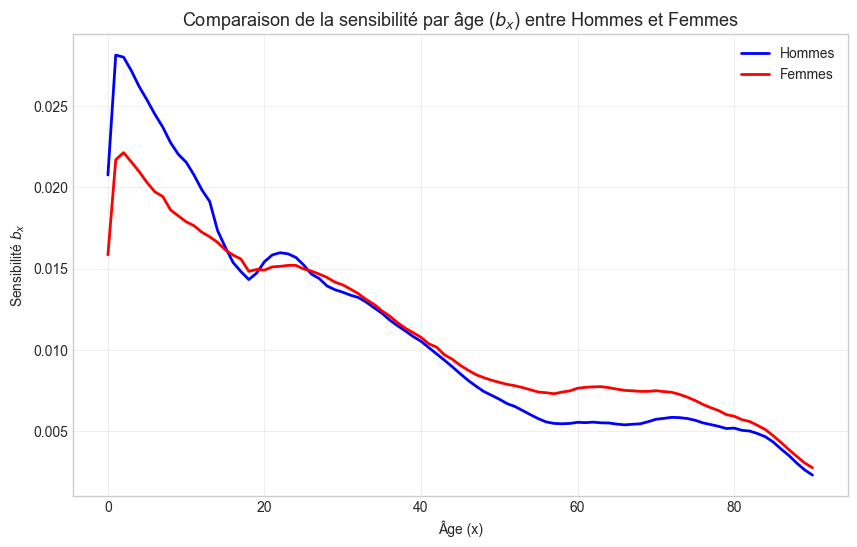

In [ ]:
plt.figure(figsize=(10, 6))

ages = np.arange(len(gender_results['Homme']['bx']))

plt.plot(ages, gender_results['Homme']['bx'], label='Hommes', color='blue', linewidth=2)
plt.plot(ages, gender_results['Femme']['bx'], label='Femmes', color='red', linewidth=2)

plt.title(r"Comparaison de la sensibilité par âge ($b_x$) entre Hommes et Femmes", fontsize=13)
plt.xlabel("Âge (x)")
plt.ylabel(r"Sensibilité $b_x$")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

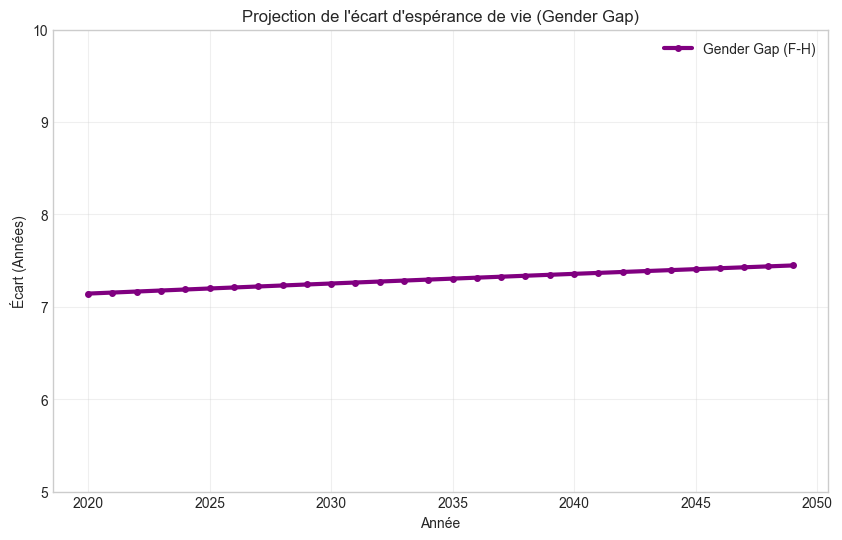

In [ ]:
e0_timeline = {'Année': np.arange(2020, 2050), 'Homme': [], 'Femme': []}

for year_idx in range(30):
    for gender in ['Homme', 'Femme']:
        res = gender_results[gender]
        
        kt_val = res['kt_proj'][year_idx]
        
        mx_proj = reconstruct_mx(res['ax'], res['bx'], [kt_val])
        
        mx_series = mx_proj.iloc[:, 0]
        
        df_input = mx_series.to_frame(name='mx').reset_index().rename(columns={'index':'Age'})
        df_input['ax'] = 0.5
        df_input['qx'] = df_input['mx'] / (1 + 0.5 * df_input['mx'])
        
        lt = compute_life_table(df_input)
        e0_timeline[gender].append(lt.iloc[0]['ex'])

df_gap = pd.DataFrame(e0_timeline)
df_gap['Gap'] = df_gap['Femme'] - df_gap['Homme']

plt.figure(figsize=(10, 6))
plt.plot(df_gap['Année'], df_gap['Gap'], color='purple', linewidth=3, marker='o', markersize=4, label="Gender Gap (F-H)")

plt.title("Projection de l'écart d'espérance de vie (Gender Gap)")
plt.xlabel("Année")
plt.ylabel("Écart (Années)")
plt.ylim(5, 10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()